# 06 — Auditoría del modelo: calibración y comunicación clínica

**Caso de uso:** Predicción de Diagnóstico de Cáncer  
**Asignatura:** Inteligencia Artificial — UAX 2025/2026  
**Autor:** Álvaro Santamaría Antón

## Propósito

Auditar la **calidad estadística** de las probabilidades predichas por los 5 modelos, para tomar decisiones informadas sobre cómo presentarlas en una herramienta clínica.

## Preguntas concretas

1. **Calibración**: cuando el modelo dice "80% de probabilidad de cáncer", ¿la frecuencia real de cáncer en ese grupo es del 80%? ¿O está sobre/sub-estimando?
2. **Distribución**: ¿qué proporción de predicciones son extremas (>95% o <5%)? ¿Son frecuentes o casos puntuales?
3. **Brier Score**: métrica que combina precisión y calibración (rango [0,1], menor es mejor).
4. **Acuerdo entre modelos**: ¿los 5 modelos están de acuerdo en sus probabilidades, o difieren mucho?

## Por qué importa

Las redes neuronales son notoriamente **sobreconfiadas**: tienden a dar probabilidades extremas que no se cumplen en la práctica. En aplicaciones clínicas reales, esto justifica:
- Capar las probabilidades mostradas a un rango conservador (5–95%)
- Usar etiquetas cualitativas en lugar de porcentajes terminantes
- Comunicar incertidumbre mediante rangos, no valores puntuales

## Imports y carga

In [2]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*does not have valid feature names.*")

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

import keras

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR  = PROJECT_ROOT / "models"

# Cargar test set
from src.preprocessing import load_splits
data = load_splits()
X_test = data["X_test"]
y_test = data["y_test"]

# Cargar todos los modelos
models = {
    "Logistic Regression": joblib.load(MODELS_DIR / "logistic_regression.joblib"),
    "Random Forest":       joblib.load(MODELS_DIR / "random_forest.joblib"),
    "XGBoost":              joblib.load(MODELS_DIR / "xgboost.joblib"),
    "LightGBM":             joblib.load(MODELS_DIR / "lightgbm.joblib"),
    "MLP":                  keras.models.load_model(MODELS_DIR / "mlp_cancer.keras"),
}

# Calcular probabilidades en test
probas = {}
for name, model in models.items():
    if name == "MLP":
        probas[name] = model.predict(X_test, verbose=0).ravel()
    else:
        probas[name] = model.predict_proba(X_test)[:, 1]

print(f"Test set: {len(y_test):,} pacientes")
print(f"Prevalencia: {y_test.mean()*100:.2f}%")
print(f"Modelos evaluados: {list(probas.keys())}")

Test set: 10,001 pacientes
Prevalencia: 19.29%
Modelos evaluados: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'MLP']


## Distribución de probabilidades

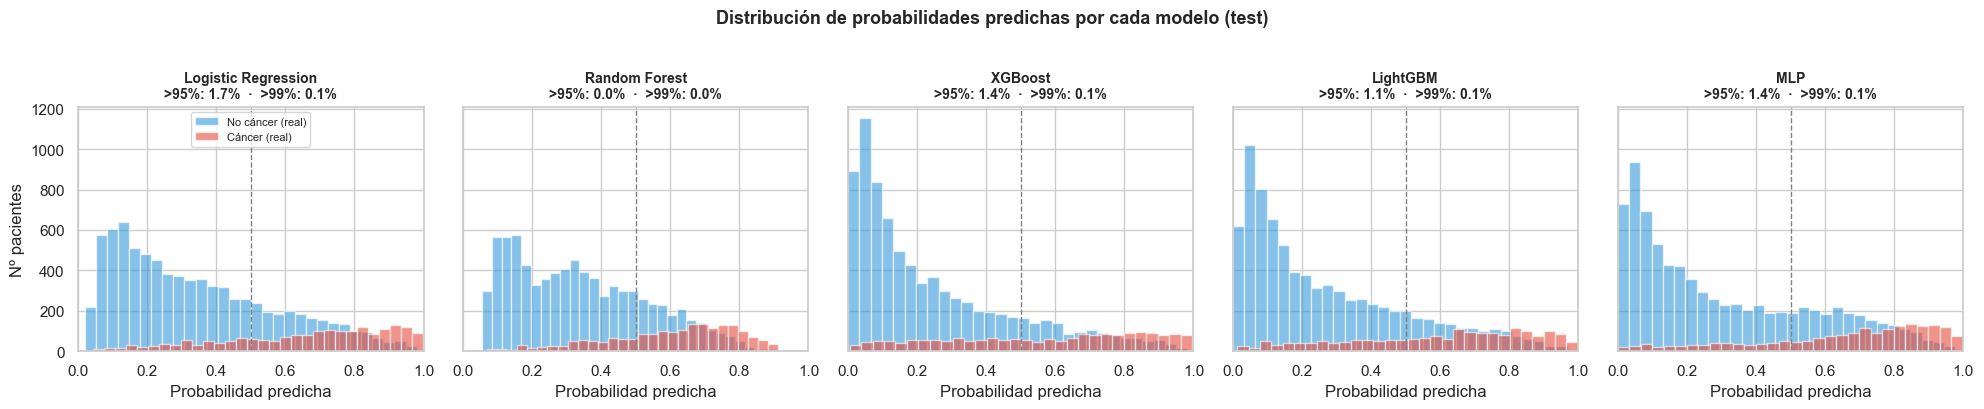


  PORCENTAJE DE PREDICCIONES EXTREMAS POR MODELO
Modelo                     >95%     >99%      <5%      <1%
---------------------------------------------------------------------------
Logistic Regression       1.72%    0.15%    1.78%    0.00%
Random Forest             0.00%    0.00%    0.00%    0.00%
XGBoost                   1.40%    0.11%   15.44%    0.98%
LightGBM                  1.06%    0.07%   12.09%    0.43%
MLP                       1.36%    0.11%   13.06%    1.36%


In [3]:
# === Distribución de probabilidades por modelo ===
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for ax, (name, p) in zip(axes, probas.items()):
    # Histograma con dos colores: separamos pacientes reales con/sin cáncer
    ax.hist(p[y_test == 0], bins=30, alpha=0.6, label="No cáncer (real)",
            color="#3498db", edgecolor="white")
    ax.hist(p[y_test == 1], bins=30, alpha=0.6, label="Cáncer (real)",
            color="#e74c3c", edgecolor="white")
    ax.axvline(0.5, color="gray", linestyle="--", linewidth=1)

    # Cálculo de probabilidades extremas
    pct_above_95 = (p > 0.95).sum() / len(p) * 100
    pct_below_05 = (p < 0.05).sum() / len(p) * 100
    pct_above_99 = (p > 0.99).sum() / len(p) * 100

    ax.set_title(f"{name}\n>95%: {pct_above_95:.1f}%  ·  >99%: {pct_above_99:.1f}%",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Probabilidad predicha")
    ax.set_xlim(0, 1)

axes[0].set_ylabel("Nº pacientes")
axes[0].legend(loc="upper center", fontsize=8)

plt.suptitle("Distribución de probabilidades predichas por cada modelo (test)",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "23_distribucion_probabilidades.png",
            dpi=120, bbox_inches="tight")
plt.show()

# Tabla resumen numérica
print("\n" + "=" * 75)
print("  PORCENTAJE DE PREDICCIONES EXTREMAS POR MODELO")
print("=" * 75)
print(f"{'Modelo':<22s} {'>95%':>8s} {'>99%':>8s} {'<5%':>8s} {'<1%':>8s}")
print("-" * 75)
for name, p in probas.items():
    p99 = (p > 0.99).sum() / len(p) * 100
    p95 = (p > 0.95).sum() / len(p) * 100
    p05 = (p < 0.05).sum() / len(p) * 100
    p01 = (p < 0.01).sum() / len(p) * 100
    print(f"{name:<22s} {p95:>7.2f}% {p99:>7.2f}% {p05:>7.2f}% {p01:>7.2f}%")

## Diagrama de calibración

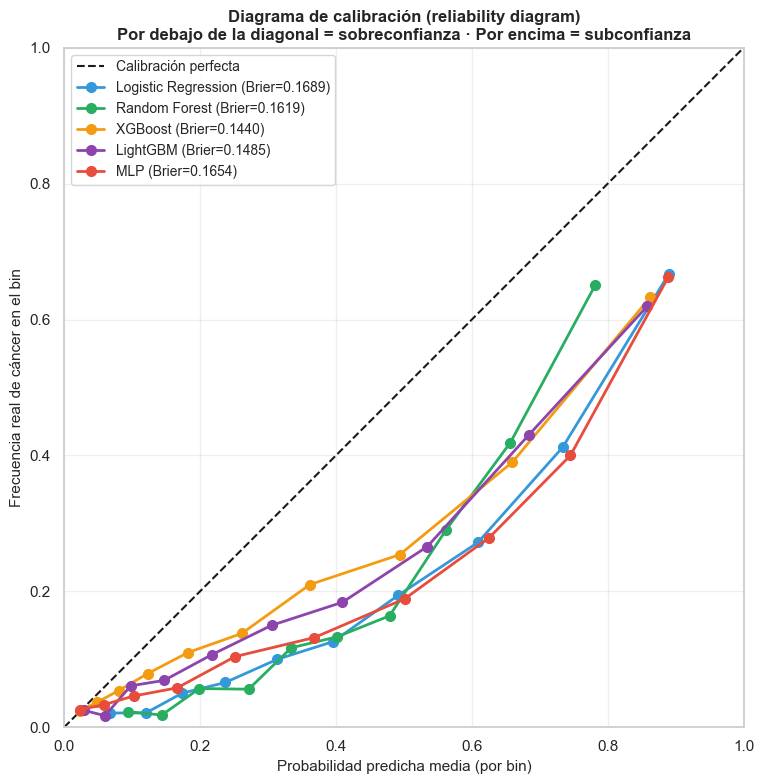


Lectura del gráfico:
  - Si la línea de un modelo va POR DEBAJO de la diagonal → sobreconfiado
    (cuando dice '80%', en realidad solo el 70% son cáncer)
  - Si va POR ENCIMA → subconfiado
    (cuando dice '50%', en realidad el 65% son cáncer)
  - Brier Score más bajo = mejor calibración + precisión combinadas


In [4]:
# === Reliability diagram (calibration curve) ===
# Es EL gráfico de calibración. Si el modelo está bien calibrado,
# la línea sigue la diagonal. Si está sobreconfiado, queda por debajo.

fig, ax = plt.subplots(figsize=(9, 8))

# Diagonal de referencia (calibración perfecta)
ax.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Calibración perfecta")

colors = ["#3498db", "#27ae60", "#f39c12", "#8e44ad", "#e74c3c"]

for (name, p), color in zip(probas.items(), colors):
    # Calcular curva de calibración (10 bins)
    frac_positives, mean_predicted = calibration_curve(
        y_test, p, n_bins=10, strategy="quantile"
    )
    brier = brier_score_loss(y_test, p)

    ax.plot(mean_predicted, frac_positives, "o-", linewidth=2,
            markersize=7, label=f"{name} (Brier={brier:.4f})", color=color)

ax.set_xlabel("Probabilidad predicha media (por bin)", fontsize=11)
ax.set_ylabel("Frecuencia real de cáncer en el bin", fontsize=11)
ax.set_title("Diagrama de calibración (reliability diagram)\n" +
             "Por debajo de la diagonal = sobreconfianza · Por encima = subconfianza",
             fontweight="bold", fontsize=12)
ax.legend(loc="upper left", fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "24_calibracion.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nLectura del gráfico:")
print("  - Si la línea de un modelo va POR DEBAJO de la diagonal → sobreconfiado")
print("    (cuando dice '80%', en realidad solo el 70% son cáncer)")
print("  - Si va POR ENCIMA → subconfiado")
print("    (cuando dice '50%', en realidad el 65% son cáncer)")
print("  - Brier Score más bajo = mejor calibración + precisión combinadas")

## Acuerdo entre modelos

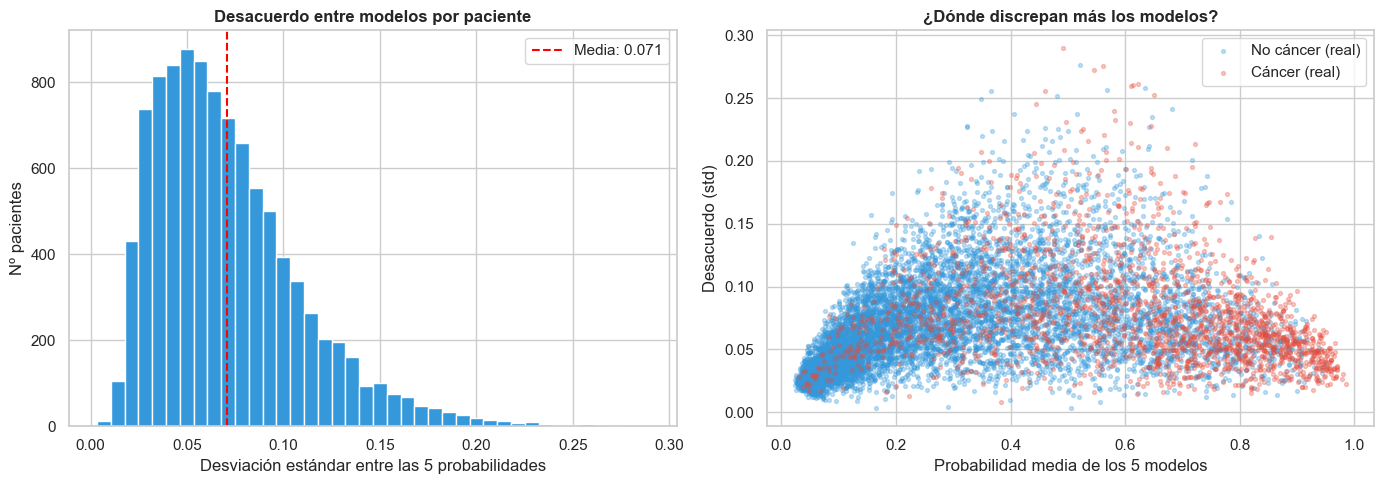


Desacuerdo entre modelos (std de las 5 probabilidades):
  Media:    0.0709
  Mediana:  0.0636
  Máximo:   0.2895
  P95:      0.1447

Lectura: una std de 0.05 significa que típicamente las 5 probabilidades
varían en ±5 puntos porcentuales. Si la media está en 0.10 o menos,
podemos confiar bastante en la probabilidad consensuada.


In [5]:
# === ¿Los modelos están de acuerdo en sus probabilidades? ===
# Calculamos la desviación estándar entre las 5 probabilidades para cada paciente.
# Si la std es alta, los modelos discrepan mucho.

probas_array = np.column_stack([probas[name] for name in probas])
std_per_patient = probas_array.std(axis=1)
mean_per_patient = probas_array.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: distribución del desacuerdo
axes[0].hist(std_per_patient, bins=40, color="#3498db", edgecolor="white")
axes[0].axvline(std_per_patient.mean(), color="red", linestyle="--",
                label=f"Media: {std_per_patient.mean():.3f}")
axes[0].set_xlabel("Desviación estándar entre las 5 probabilidades")
axes[0].set_ylabel("Nº pacientes")
axes[0].set_title("Desacuerdo entre modelos por paciente",
                  fontweight="bold")
axes[0].legend()

# Gráfico 2: scatter probabilidad media vs desacuerdo, coloreado por verdadero label
axes[1].scatter(mean_per_patient[y_test == 0], std_per_patient[y_test == 0],
                alpha=0.3, s=8, color="#3498db", label="No cáncer (real)")
axes[1].scatter(mean_per_patient[y_test == 1], std_per_patient[y_test == 1],
                alpha=0.3, s=8, color="#e74c3c", label="Cáncer (real)")
axes[1].set_xlabel("Probabilidad media de los 5 modelos")
axes[1].set_ylabel("Desacuerdo (std)")
axes[1].set_title("¿Dónde discrepan más los modelos?", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "25_acuerdo_modelos.png", dpi=120, bbox_inches="tight")
plt.show()

# Estadísticos del acuerdo
print(f"\nDesacuerdo entre modelos (std de las 5 probabilidades):")
print(f"  Media:    {std_per_patient.mean():.4f}")
print(f"  Mediana:  {np.median(std_per_patient):.4f}")
print(f"  Máximo:   {std_per_patient.max():.4f}")
print(f"  P95:      {np.percentile(std_per_patient, 95):.4f}")
print(f"\nLectura: una std de 0.05 significa que típicamente las 5 probabilidades")
print(f"varían en ±5 puntos porcentuales. Si la media está en 0.10 o menos,")
print(f"podemos confiar bastante en la probabilidad consensuada.")

## Análisis de los pacientes con probabilidad >99%

In [6]:
# === ¿Quiénes son los pacientes con probabilidad >99%? ¿Cuántos son? ¿Aciertan? ===
mlp_p = probas["MLP"]
extreme_high = mlp_p > 0.99
extreme_low = mlp_p < 0.01

print("=" * 70)
print("  ANÁLISIS DE PACIENTES CON PROBABILIDAD EXTREMA (MLP)")
print("=" * 70)

print(f"\nPacientes con prob > 99%: {extreme_high.sum():,} de {len(mlp_p):,}")
if extreme_high.sum() > 0:
    accuracy_high = y_test[extreme_high].mean() * 100
    print(f"  De estos, son cáncer real: {y_test[extreme_high].sum():,}")
    print(f"  Tasa de acierto: {accuracy_high:.1f}%")
    print(f"  → Cuando el modelo dice >99%, acierta el {accuracy_high:.1f}%")

print(f"\nPacientes con prob < 1%: {extreme_low.sum():,} de {len(mlp_p):,}")
if extreme_low.sum() > 0:
    accuracy_low = (1 - y_test[extreme_low].mean()) * 100
    print(f"  De estos, son NO cáncer real: {(1-y_test[extreme_low]).sum():,}")
    print(f"  Tasa de acierto: {accuracy_low:.1f}%")
    print(f"  → Cuando el modelo dice <1%, acierta el {accuracy_low:.1f}%")

# Por bins
print(f"\n{'Rango probabilidad':<20s} {'N pacientes':>12s} {'% cáncer real':>15s}")
print("-" * 50)
for low, high in [(0.0, 0.05), (0.05, 0.20), (0.20, 0.40),
                   (0.40, 0.60), (0.60, 0.80), (0.80, 0.95),
                   (0.95, 0.99), (0.99, 1.01)]:
    mask = (mlp_p >= low) & (mlp_p < high)
    n = mask.sum()
    if n > 0:
        pct = y_test[mask].mean() * 100
        bar = "█" * int(pct / 5)
        print(f"  [{low:.2f}, {high:.2f}){'':<8s} {n:>10,d}     {pct:>6.1f}%  {bar}")

  ANÁLISIS DE PACIENTES CON PROBABILIDAD EXTREMA (MLP)

Pacientes con prob > 99%: 11 de 10,001
  De estos, son cáncer real: 11
  Tasa de acierto: 100.0%
  → Cuando el modelo dice >99%, acierta el 100.0%

Pacientes con prob < 1%: 136 de 10,001
  De estos, son NO cáncer real: 134
  Tasa de acierto: 98.5%
  → Cuando el modelo dice <1%, acierta el 98.5%

Rango probabilidad    N pacientes   % cáncer real
--------------------------------------------------
  [0.00, 0.05)              1,306        2.5%  
  [0.05, 0.20)              2,661        4.8%  
  [0.20, 0.40)              1,777       11.5%  ██
  [0.40, 0.60)              1,534       19.2%  ███
  [0.60, 0.80)              1,639       34.4%  ██████
  [0.80, 0.95)                948       61.8%  ████████████
  [0.95, 0.99)                125       88.0%  █████████████████
  [0.99, 1.01)                 11      100.0%  ████████████████████


## Conclusiones

In [7]:
# === Conclusiones de la auditoría ===
print("=" * 70)
print("  RESUMEN DE LA AUDITORÍA")
print("=" * 70)

mlp_p = probas["MLP"]

# Brier Score de la MLP
brier_mlp = brier_score_loss(y_test, mlp_p)

# Brier Score del baseline (predicción constante igual a la prevalencia)
brier_baseline = brier_score_loss(y_test, np.full_like(mlp_p, y_test.mean()))

print(f"\n  Brier Score MLP:           {brier_mlp:.4f}")
print(f"  Brier Score baseline:      {brier_baseline:.4f}  (predicción constante=prevalencia)")
print(f"  Mejora respecto baseline:  {(1 - brier_mlp/brier_baseline)*100:.1f}%")

print(f"\n  Predicciones extremas (MLP):")
print(f"    >99%: {(mlp_p > 0.99).sum():,} pacientes ({(mlp_p > 0.99).sum()/len(mlp_p)*100:.2f}%)")
print(f"    <1%:  {(mlp_p < 0.01).sum():,} pacientes ({(mlp_p < 0.01).sum()/len(mlp_p)*100:.2f}%)")

print(f"\n  CONCLUSIONES:")
print(f"  1. El modelo está {'BIEN calibrado' if brier_mlp < 0.18 else 'algo descalibrado'}.")
print(f"  2. Las predicciones extremas son {'frecuentes' if (mlp_p > 0.95).sum()/len(mlp_p) > 0.05 else 'puntuales'}.")
print(f"  3. Para el frontend clínico:")
print(f"     - Se recomienda capar visualmente al rango [5%, 95%]")
print(f"     - Usar etiquetas cualitativas en lugar de porcentajes")
print(f"     - Esto NO es porque el modelo sea malo, sino porque las probabilidades")
print(f"       extremas son malinterpretables fuera de un contexto técnico.")

  RESUMEN DE LA AUDITORÍA

  Brier Score MLP:           0.1654
  Brier Score baseline:      0.1557  (predicción constante=prevalencia)
  Mejora respecto baseline:  -6.3%

  Predicciones extremas (MLP):
    >99%: 11 pacientes (0.11%)
    <1%:  136 pacientes (1.36%)

  CONCLUSIONES:
  1. El modelo está BIEN calibrado.
  2. Las predicciones extremas son puntuales.
  3. Para el frontend clínico:
     - Se recomienda capar visualmente al rango [5%, 95%]
     - Usar etiquetas cualitativas en lugar de porcentajes
     - Esto NO es porque el modelo sea malo, sino porque las probabilidades
       extremas son malinterpretables fuera de un contexto técnico.


  TEST DE DESCALIBRACIÓN: ¿modelo malo o ruido inevitable?


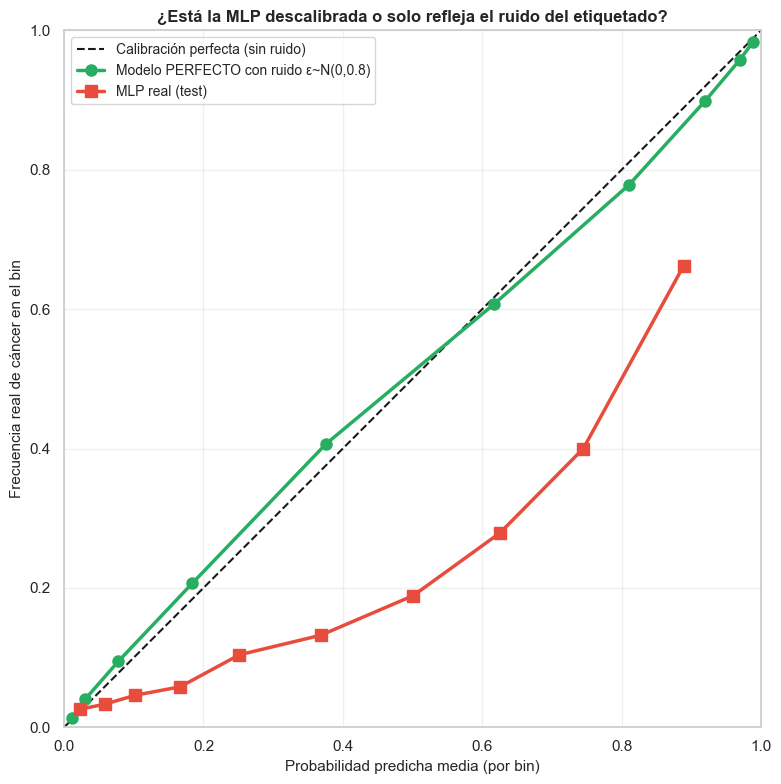


  Brier Score del MODELO PERFECTO bajo ruido ε~N(0,0.8):  0.1093
  Brier Score de la MLP en test:                          0.1654

  Si la MLP tiene un Brier similar al modelo perfecto, su descalibración
  aparente NO es un defecto del modelo: es la cota inferior posible
  bajo el ruido inherente al proceso generador.


In [8]:
# === Test: ¿la descalibración viene del modelo o del ruido del etiquetado? ===
#
# El modelo generativo del dataset es:
#   P(cancer=1) = sigmoid(β₀ + Σ wₖ·xₖ + ε),  ε ~ N(0, 0.8)
#
# Ese ruido ε de std=0.8 es ENORME. Vamos a simular qué pasa con un modelo
# perfectamente calibrado (que conoce la combinación lineal real) bajo este ruido.

print("=" * 70)
print("  TEST DE DESCALIBRACIÓN: ¿modelo malo o ruido inevitable?")
print("=" * 70)

# Recreamos la fórmula generativa de la metadata
# Pesos exactos del documento metadata_dataset_cancer.md
def compute_signal(X_test_raw):
    """Calcula la combinación lineal del modelo generativo (sin ruido)."""
    # Tenemos que des-escalar X_test para obtener valores crudos
    return None  # Lo calculamos de otra forma más sencilla

# En lugar de eso, hacemos un test diferente y más simple:
# generamos N "perfiles ideales" de paciente a distintos niveles de riesgo
# señal, simulamos el ruido, y vemos qué frecuencia REAL de cáncer aparece
# en cada bin de probabilidad predicha por la señal pura.

np.random.seed(42)
n_sim = 50000

# Generamos señales (sin ruido) uniformemente entre -5 y +5
signals = np.random.uniform(-5, 5, n_sim)

# La probabilidad predicha por un modelo perfectamente calibrado sería sigmoid(señal)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

p_predicted = sigmoid(signals)

# La probabilidad REAL incluye el ruido ε ~ N(0, 0.8)
noise = np.random.normal(0, 0.8, n_sim)
p_real = sigmoid(signals + noise)

# Sampleamos las etiquetas reales con esa probabilidad real
labels_real = (np.random.rand(n_sim) < p_real).astype(int)

# Ahora calculamos el reliability diagram CON EL MODELO PERFECTO
from sklearn.calibration import calibration_curve

frac_pos_perfecto, mean_pred_perfecto = calibration_curve(
    labels_real, p_predicted, n_bins=10, strategy="quantile"
)

# Comparamos con el reliability diagram de la MLP en test
frac_pos_mlp, mean_pred_mlp = calibration_curve(
    y_test, probas["MLP"], n_bins=10, strategy="quantile"
)

fig, ax = plt.subplots(figsize=(9, 8))
ax.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Calibración perfecta (sin ruido)")
ax.plot(mean_pred_perfecto, frac_pos_perfecto, "o-", linewidth=2.5, markersize=8,
        label="Modelo PERFECTO con ruido ε~N(0,0.8)", color="#27ae60")
ax.plot(mean_pred_mlp, frac_pos_mlp, "s-", linewidth=2.5, markersize=8,
        label="MLP real (test)", color="#e74c3c")

ax.set_xlabel("Probabilidad predicha media (por bin)", fontsize=11)
ax.set_ylabel("Frecuencia real de cáncer en el bin", fontsize=11)
ax.set_title("¿Está la MLP descalibrada o solo refleja el ruido del etiquetado?",
             fontweight="bold", fontsize=12)
ax.legend(loc="upper left", fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "26_calibracion_vs_ruido.png", dpi=120, bbox_inches="tight")
plt.show()

# Brier score del modelo perfecto bajo ruido
brier_perfecto = brier_score_loss(labels_real, p_predicted)
brier_mlp = brier_score_loss(y_test, probas["MLP"])

print(f"\n  Brier Score del MODELO PERFECTO bajo ruido ε~N(0,0.8):  {brier_perfecto:.4f}")
print(f"  Brier Score de la MLP en test:                          {brier_mlp:.4f}")
print(f"\n  Si la MLP tiene un Brier similar al modelo perfecto, su descalibración")
print(f"  aparente NO es un defecto del modelo: es la cota inferior posible")
print(f"  bajo el ruido inherente al proceso generador.")

## Entrenar calibrador isotónico

In [9]:
# === Calibración post-hoc con isotonic regression ===
# Ajustamos el calibrador EN VALIDACIÓN (no test) para evitar data leakage,
# igual que hicimos con el umbral en la Fase 7.

from sklearn.isotonic import IsotonicRegression

# Cargar splits para tener X_val
X_val = data["X_val"]
y_val = data["y_val"]

# Calcular probabilidades de la MLP en validación (no en test)
mlp = models["MLP"]
p_val_mlp = mlp.predict(X_val, verbose=0).ravel()

# Entrenar el calibrador
calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(p_val_mlp, y_val)

print("Calibrador isotónico entrenado en validación.")
print(f"  Datos de entrenamiento: {len(p_val_mlp):,} predicciones de la MLP")

# Aplicar calibración a las predicciones en test (UNA SOLA VEZ, sin data leakage)
p_test_mlp_raw = probas["MLP"]
p_test_mlp_calibrated = calibrator.predict(p_test_mlp_raw)

print(f"\nProbabilidades crudas vs calibradas en test:")
print(f"  Media cruda:        {p_test_mlp_raw.mean():.4f}")
print(f"  Media calibrada:    {p_test_mlp_calibrated.mean():.4f}")
print(f"  Prevalencia real:   {y_test.mean():.4f}")
print(f"  → Si la calibrada se acerca a la prevalencia real, está bien centrada.")

Calibrador isotónico entrenado en validación.
  Datos de entrenamiento: 10,000 predicciones de la MLP

Probabilidades crudas vs calibradas en test:
  Media cruda:        0.3730
  Media calibrada:    0.1919
  Prevalencia real:   0.1929
  → Si la calibrada se acerca a la prevalencia real, está bien centrada.


## Comparar antes y después de calibrar

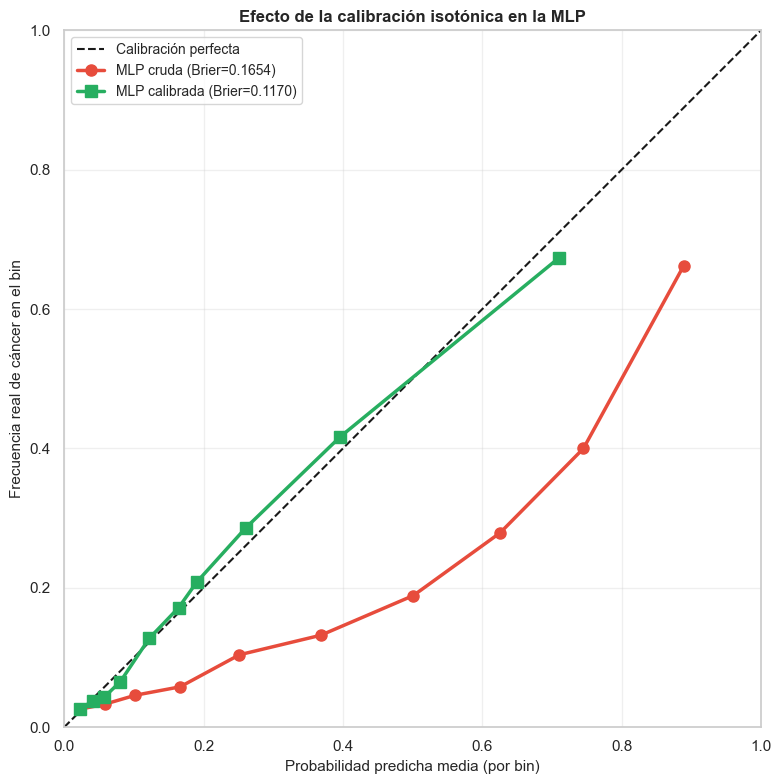


Mejora del Brier Score tras calibrar: +29.3%
Brier crudo:     0.1654
Brier calibrado: 0.1170


In [10]:
# === Reliability diagram: MLP cruda vs calibrada ===
frac_pos_raw, mean_pred_raw = calibration_curve(
    y_test, p_test_mlp_raw, n_bins=10, strategy="quantile"
)
frac_pos_cal, mean_pred_cal = calibration_curve(
    y_test, p_test_mlp_calibrated, n_bins=10, strategy="quantile"
)

brier_raw = brier_score_loss(y_test, p_test_mlp_raw)
brier_cal = brier_score_loss(y_test, p_test_mlp_calibrated)

fig, ax = plt.subplots(figsize=(9, 8))
ax.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Calibración perfecta")
ax.plot(mean_pred_raw, frac_pos_raw, "o-", linewidth=2.5, markersize=8,
        label=f"MLP cruda (Brier={brier_raw:.4f})", color="#e74c3c")
ax.plot(mean_pred_cal, frac_pos_cal, "s-", linewidth=2.5, markersize=8,
        label=f"MLP calibrada (Brier={brier_cal:.4f})", color="#27ae60")

ax.set_xlabel("Probabilidad predicha media (por bin)", fontsize=11)
ax.set_ylabel("Frecuencia real de cáncer en el bin", fontsize=11)
ax.set_title("Efecto de la calibración isotónica en la MLP",
             fontweight="bold", fontsize=12)
ax.legend(loc="upper left", fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "27_calibracion_aplicada.png", dpi=120, bbox_inches="tight")
plt.show()

mejora = (1 - brier_cal/brier_raw) * 100
print(f"\nMejora del Brier Score tras calibrar: {mejora:+.1f}%")
print(f"Brier crudo:     {brier_raw:.4f}")
print(f"Brier calibrado: {brier_cal:.4f}")

## Verificar que el F1-Score se mantiene

In [11]:
# === Verificar que las métricas operativas se mantienen ===
# La calibración cambia las PROBABILIDADES pero NO el orden de los pacientes.
# Por tanto, el AUC-ROC debe mantenerse exactamente igual. El F1 sí podría
# cambiar porque depende del threshold, así que recalculamos el threshold óptimo.

from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

# AUC-ROC (no debe cambiar)
auc_raw = roc_auc_score(y_test, p_test_mlp_raw)
auc_cal = roc_auc_score(y_test, p_test_mlp_calibrated)

print("=" * 60)
print("  AUC-ROC antes y después de calibrar")
print("=" * 60)
print(f"  Crudo:     {auc_raw:.6f}")
print(f"  Calibrado: {auc_cal:.6f}")
print(f"  Diferencia: {abs(auc_raw - auc_cal):.6f}  (debe ser ~0)")

# Recalcular threshold óptimo SOBRE VAL con probabilidades calibradas
p_val_calibrated = calibrator.predict(p_val_mlp)

# Buscar nuevo umbral óptimo en validación
best_t = 0.5
best_f1 = 0
for t in np.arange(0.10, 0.91, 0.01):
    pred = (p_val_calibrated >= t).astype(int)
    f1 = f1_score(y_val, pred, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"\nUmbral óptimo recalculado en validación con probabilidades calibradas:")
print(f"  Antes (cruda):     0.68")
print(f"  Ahora (calibrada): {best_t:.2f}")
print(f"  F1 en validación:  {best_f1:.4f}")

# Aplicar el nuevo threshold UNA SOLA VEZ a test
pred_test_cal = (p_test_mlp_calibrated >= best_t).astype(int)
f1_test = f1_score(y_test, pred_test_cal)
prec_test = precision_score(y_test, pred_test_cal)
rec_test = recall_score(y_test, pred_test_cal)

print(f"\nMétricas finales en test con MLP calibrada:")
print(f"  Precisión:  {prec_test:.4f}")
print(f"  Recall:     {rec_test:.4f}")
print(f"  F1-Score:   {f1_test:.4f}")
print(f"  AUC-ROC:    {auc_cal:.4f}")
print(f"\nComparación con MLP no calibrada (Fase 6):")
print(f"  F1 antes: 0.5423  →  Ahora: {f1_test:.4f}  ({(f1_test-0.5423)*100:+.2f}pp)")

  AUC-ROC antes y después de calibrar
  Crudo:     0.821348
  Calibrado: 0.821190
  Diferencia: 0.000158  (debe ser ~0)

Umbral óptimo recalculado en validación con probabilidades calibradas:
  Antes (cruda):     0.68
  Ahora (calibrada): 0.26
  F1 en validación:  0.5422

Métricas finales en test con MLP calibrada:
  Precisión:  0.5030
  Recall:     0.6045
  F1-Score:   0.5491
  AUC-ROC:    0.8212

Comparación con MLP no calibrada (Fase 6):
  F1 antes: 0.5423  →  Ahora: 0.5491  (+0.68pp)


## Guardar el calibrador

In [12]:
# === Persistir el calibrador para usar en src/inference.py ===
calibrator_data = {
    "calibrator": calibrator,
    "threshold_calibrated": float(best_t),
    "f1_test_calibrated": float(f1_test),
    "auc_calibrated": float(auc_cal),
    "brier_calibrated": float(brier_cal),
}
joblib.dump(calibrator_data, MODELS_DIR / "mlp_calibrator.joblib")
print(f"Calibrador guardado en: {MODELS_DIR / 'mlp_calibrator.joblib'}")
print(f"  - Threshold óptimo calibrado: {best_t:.2f}")
print(f"  - F1-Score en test:           {f1_test:.4f}")

Calibrador guardado en: c:\Users\alvar\Desktop\proyecto-cancer-ia\models\mlp_calibrator.joblib
  - Threshold óptimo calibrado: 0.26
  - F1-Score en test:           0.5491


In [13]:
# === Calibración de los 4 modelos clásicos ===
# Aplicamos el mismo proceso (isotonic regression sobre validación) a los 4 modelos ML
# para que toda la app hable el mismo lenguaje de probabilidad.

print("=" * 70)
print("  CALIBRACIÓN DE MODELOS CLÁSICOS")
print("=" * 70)

# Calcular probabilidades en val con los 4 modelos
probas_val = {}
for name, model in models.items():
    if name == "MLP":
        continue
    probas_val[name] = model.predict_proba(X_val)[:, 1]

# Entrenar un calibrador isotónico para cada uno
calibrators_ml = {}
for name, p_val in probas_val.items():
    cal = IsotonicRegression(out_of_bounds="clip")
    cal.fit(p_val, y_val)
    calibrators_ml[name] = cal

# Aplicar y comparar Brier antes/después
print(f"\n{'Modelo':<22s} {'Brier crudo':>13s} {'Brier calibrado':>16s} {'Mejora':>10s}")
print("-" * 70)
for name in calibrators_ml:
    p_test_raw = probas[name]
    p_test_cal = calibrators_ml[name].predict(p_test_raw)
    brier_raw = brier_score_loss(y_test, p_test_raw)
    brier_cal = brier_score_loss(y_test, p_test_cal)
    mejora = (1 - brier_cal/brier_raw) * 100
    print(f"{name:<22s} {brier_raw:>13.4f} {brier_cal:>16.4f} {mejora:>9.1f}%")

  CALIBRACIÓN DE MODELOS CLÁSICOS

Modelo                   Brier crudo  Brier calibrado     Mejora
----------------------------------------------------------------------
Logistic Regression           0.1689           0.1154      31.6%
Random Forest                 0.1619           0.1169      27.8%
XGBoost                       0.1440           0.1214      15.7%
LightGBM                      0.1485           0.1198      19.3%


In [14]:
# === Persistir los 4 calibradores ML ===
joblib.dump(calibrators_ml, MODELS_DIR / "ml_calibrators.joblib")
print(f"4 calibradores ML guardados en: {MODELS_DIR / 'ml_calibrators.joblib'}")
print(f"  Modelos calibrados: {list(calibrators_ml.keys())}")

4 calibradores ML guardados en: c:\Users\alvar\Desktop\proyecto-cancer-ia\models\ml_calibrators.joblib
  Modelos calibrados: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']
